In [35]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

In [36]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [37]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [38]:
df.fillna(df['Age'].mean(), inplace=True)

In [39]:
X = df.iloc[:,1:3]
X.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [40]:
X_New = df.iloc[:,2]
X_New

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [41]:
y = df.iloc[:,0]
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

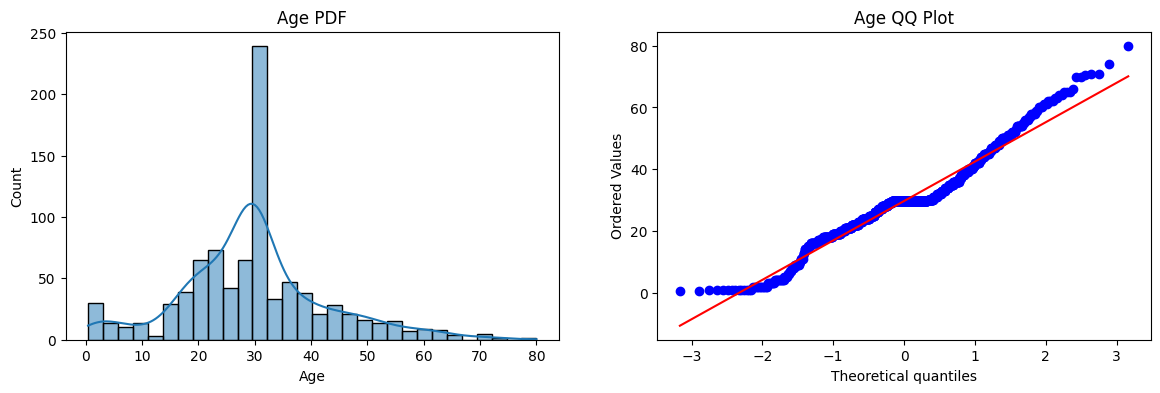

In [42]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

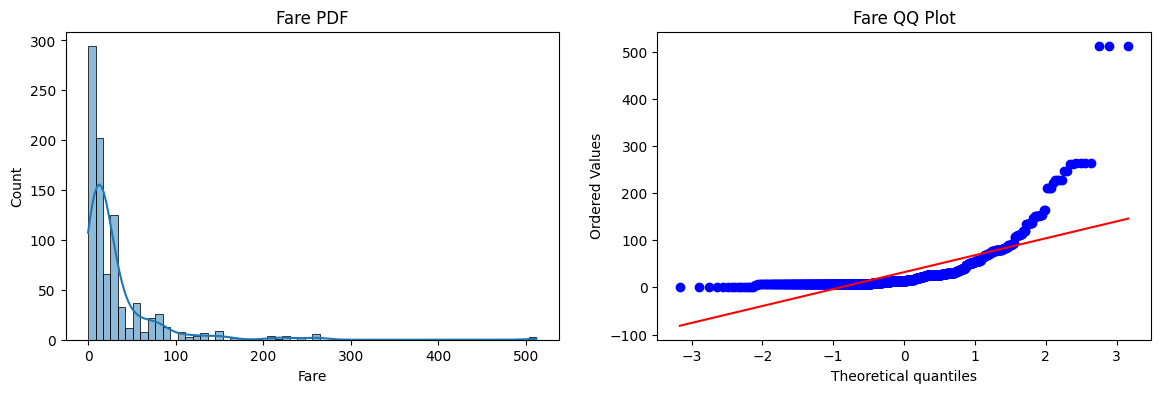

In [43]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [44]:
trf = FunctionTransformer(func=np.log1p)

In [45]:
X_transform = trf.transform(X)

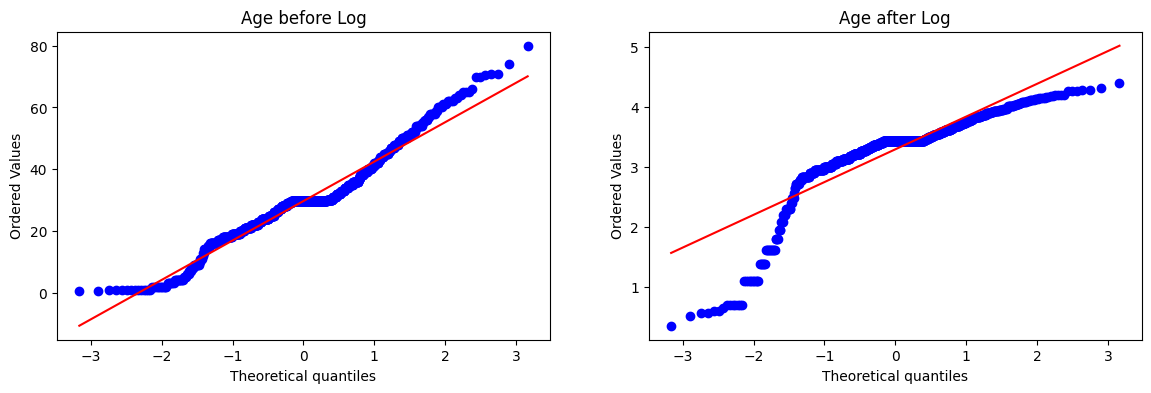

In [46]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X['Age'], dist="norm",plot=plt)
plt.title('Age before Log')

plt.subplot(122)
stats.probplot(X_transform['Age'], dist="norm", plot=plt)
plt.title('Age after Log')

plt.show()

In [47]:
trf2 = pd.DataFrame(trf.transform(X_New))

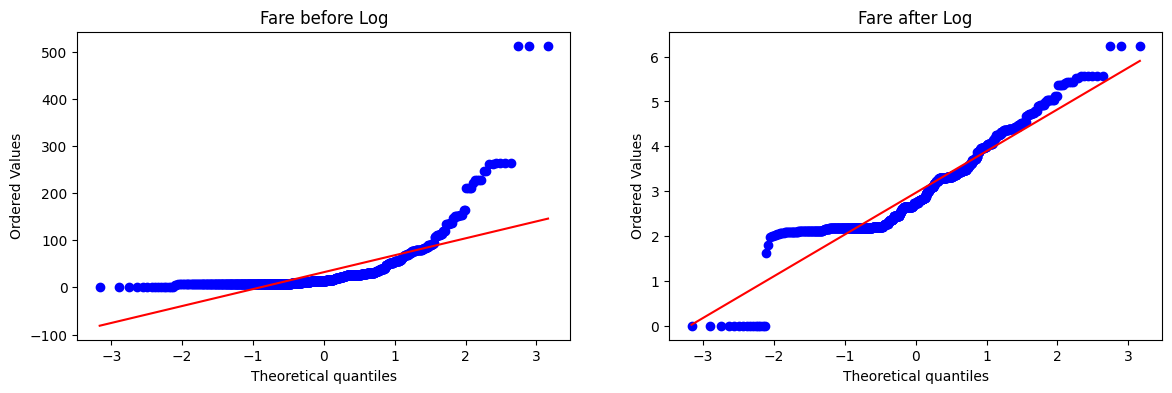

In [48]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X['Fare'],dist="norm",plot=plt)
plt.title('Fare before Log')

plt.subplot(122)
stats.probplot(trf2['Fare'], dist="norm", plot=plt)
plt.title('Fare after Log')

plt.show()

In [49]:
trf = FunctionTransformer(func=np.sin)

In [50]:
trf3 = pd.DataFrame(trf.transform(X_New))

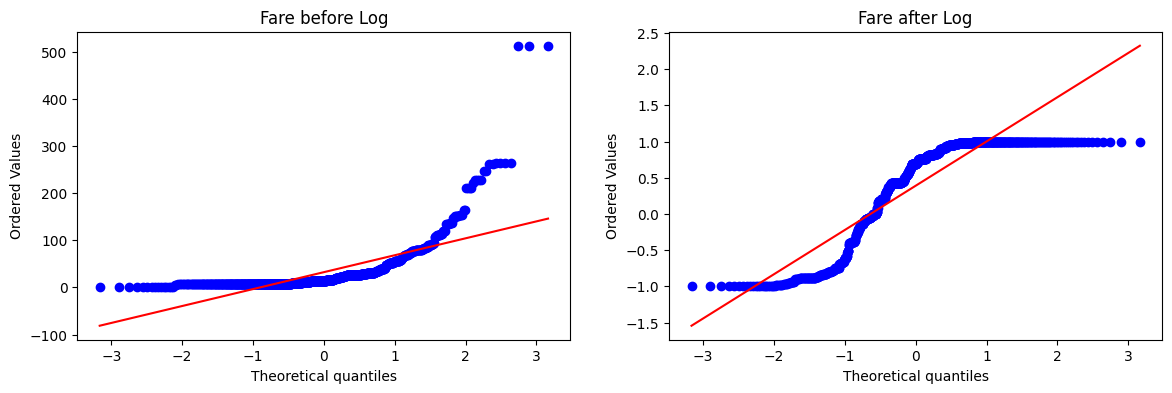

In [51]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X['Fare'],dist="norm",plot=plt)
plt.title('Fare before Log')

plt.subplot(122)
stats.probplot(trf3['Fare'], dist="norm", plot=plt)
plt.title('Fare after Log')

plt.show()

In [52]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_transform = trf.fit_transform(X)
    lr = LogisticRegression()

    print('Accuracy Score:', np.mean(cross_val_score(lr, X_transform, y,scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X['Fare'],dist='norm',plot=plt)
    plt.title('Fare before Log')

    plt.subplot(122)
    stats.probplot(X_transform[:,0],dist='norm',plot=plt)
    plt.title('Fare after Log')

    plt.show()

Accuracy Score: 0.6589013732833957


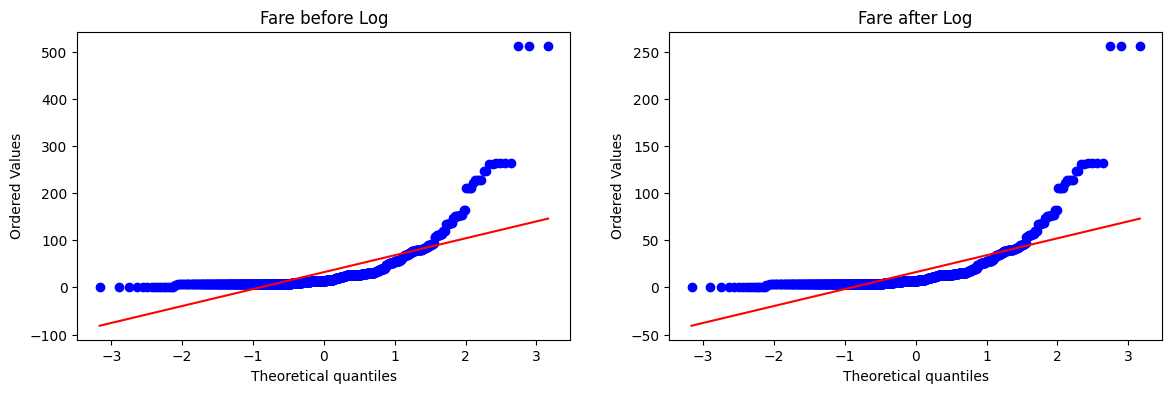

In [53]:
apply_transform(lambda x: x**1/2)

In [54]:
df1 = pd.read_csv('concrete_data.csv')
df1.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [55]:
X_data = df1.iloc[:,0:8]
X_data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [56]:
y_data = pd.DataFrame(df1.iloc[:,8])
y_data.head()

,Strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30


In [57]:
df1.shape
print(df1.columns.tolist())

['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength']


In [60]:
def apply_transform_1(transform, col=''):
    X_data = df1.iloc[:, 0:8]
    y_data = df1.iloc[:, 8]

    trf = ColumnTransformer([('log', FunctionTransformer(transform), [col])], remainder='passthrough')

    X_transform = trf.fit_transform(X_data)
    lr = LinearRegression()

    print('R² Score:', np.mean(cross_val_score(lr, X_transform, y_data, scoring='r2', cv=10)))

    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    stats.probplot(X_data[col], dist='norm', plot=plt)
    plt.title(f'{col} before Log')

    plt.subplot(122)
    stats.probplot(X_transform[:, 0], dist='norm', plot=plt)
    plt.title(f'{col} after Log')

    plt.show()

R² Score: 0.27247452584216064


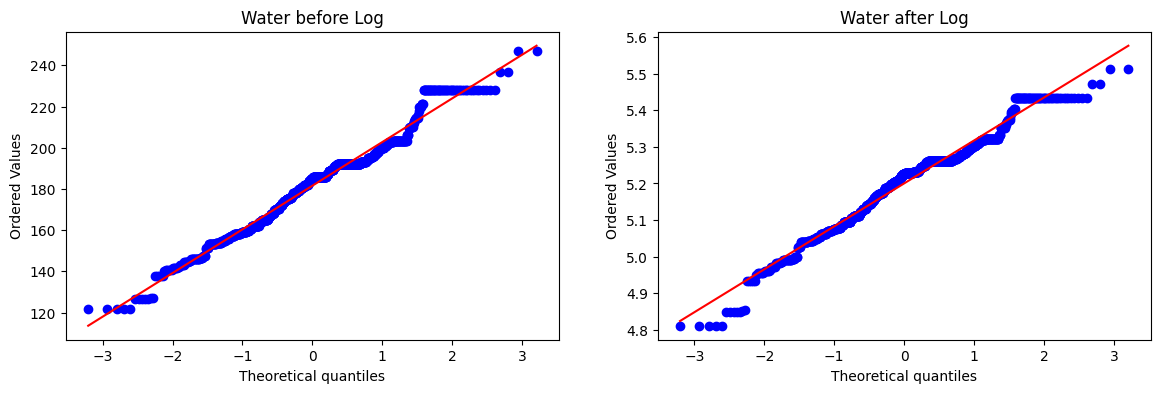

In [62]:
apply_transform_1(np.log1p,col='Water')